## import libraries and data

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [198]:
df = pd.read_csv('Mall_Customers.csv')
data = pd.read_csv('Mall_Customers.csv')
df.head()
data = pd.read_csv('Mall_Customers.csv')


In [199]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [200]:
df.sample()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
5,6,Female,22,17,76


In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [202]:
df.duplicated().sum()

np.int64(0)

In [203]:
na = df.isna().sum()
na[na>1]

Series([], dtype: int64)

In [204]:
df.describe().round()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0,200.0
mean,100.0,39.0,61.0,50.0
std,58.0,14.0,26.0,26.0
min,1.0,18.0,15.0,1.0
25%,51.0,29.0,42.0,35.0
50%,100.0,36.0,62.0,50.0
75%,150.0,49.0,78.0,73.0
max,200.0,70.0,137.0,99.0


## Data preprocessing

In [205]:
lab = LabelEncoder()
df['Gender'] = lab.fit_transform(df['Gender'])

In [206]:
# df.drop(columns='CustomerID',axis=1, inplace=True)

In [207]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [208]:
# scl = StandardScaler()
# df = scl.fit_transform(df)

In [209]:
n_clusters = []
I = []

In [210]:
for i in range(1,15):
     model = KMeans(n_clusters=i) 
     model.fit(df)
     model.inertia_
     n_clusters.append(i)
     I.append(round(model.inertia_))

In [211]:
print(len(n_clusters))
print(len(I))

14
14


In [212]:
result = pd.DataFrame({'n_clusters':n_clusters,'I':I})
result

,n_clusters,I
0,1,975512
1,2,387066
2,3,271766
3,4,195401
4,5,164683
5,6,122671
6,7,105736
7,8,86277
8,9,77659
9,10,70400


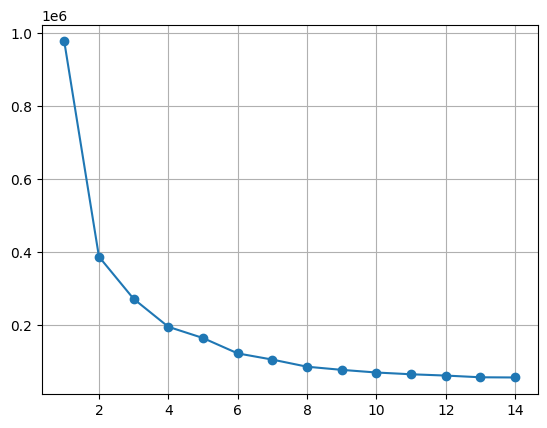

In [213]:
plt.plot(n_clusters,I,marker='o')
plt.grid()

In [214]:
model = KMeans(n_clusters=4)
model.fit(df)
pred = model.predict(df)
data['cluster'] = pred

In [215]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


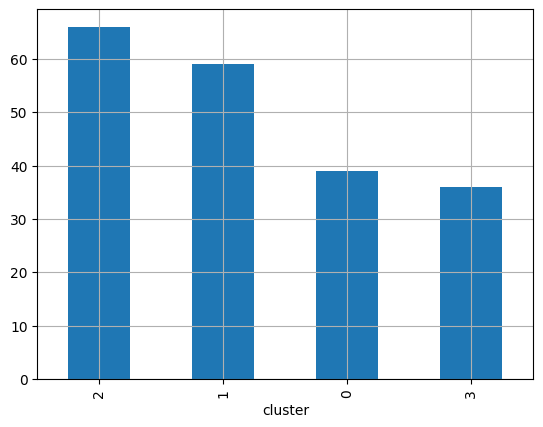

In [216]:
data['cluster'].value_counts().plot.bar()
plt.grid()

In [217]:
df1 = data.loc[data['cluster']==0]
df2 = data.loc[data['cluster']==1]
df3 = data.loc[data['cluster']==2]
df4 = data.loc[data['cluster']==3]

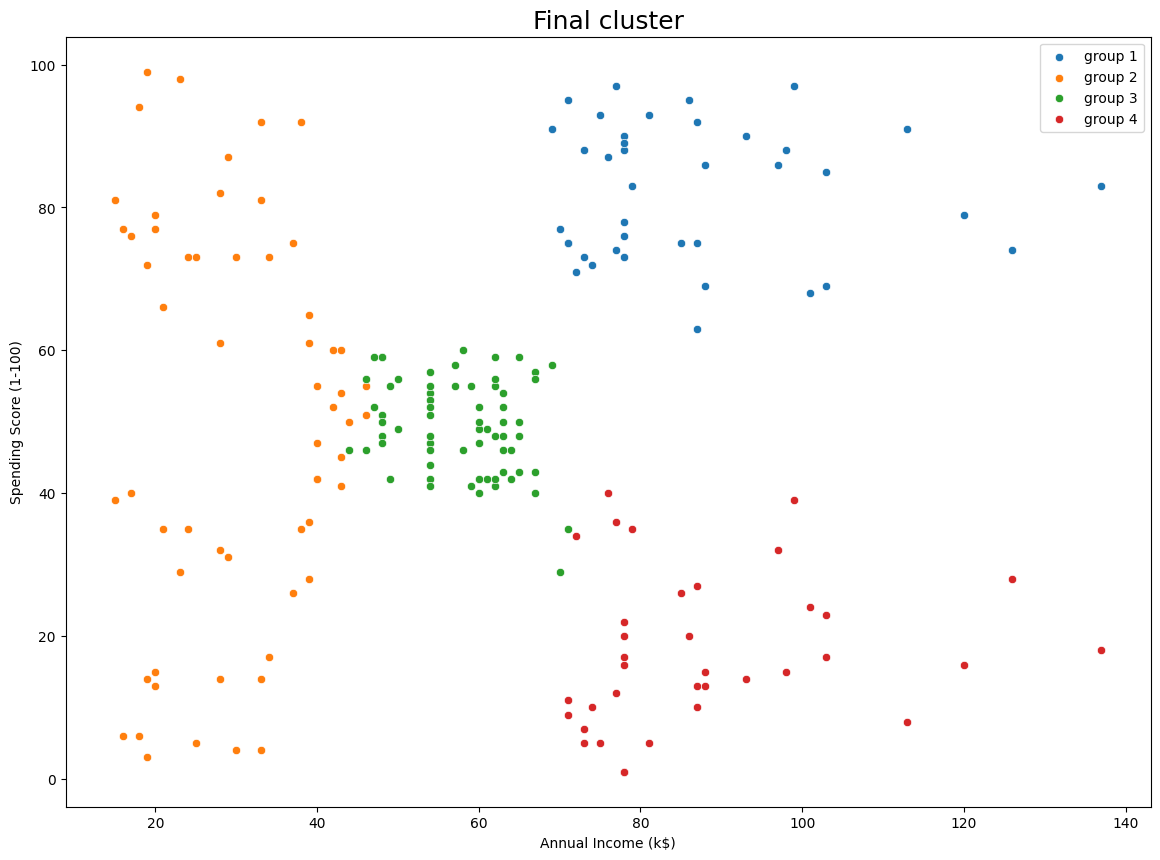

In [227]:
fig, ax = plt.subplots(figsize=(14,10))

sns.scatterplot(data=df1, x='Annual Income (k$)', y='Spending Score (1-100)', ax=ax, label='group 1')
sns.scatterplot(data=df2, x='Annual Income (k$)', y='Spending Score (1-100)', ax=ax, label='group 2')
sns.scatterplot(data=df3, x='Annual Income (k$)', y='Spending Score (1-100)', ax=ax, label='group 3')
sns.scatterplot(data=df4, x='Annual Income (k$)', y='Spending Score (1-100)', ax=ax, label='group 4')

ax.set_title('Final cluster', fontsize=18)
ax.legend()
plt.show()


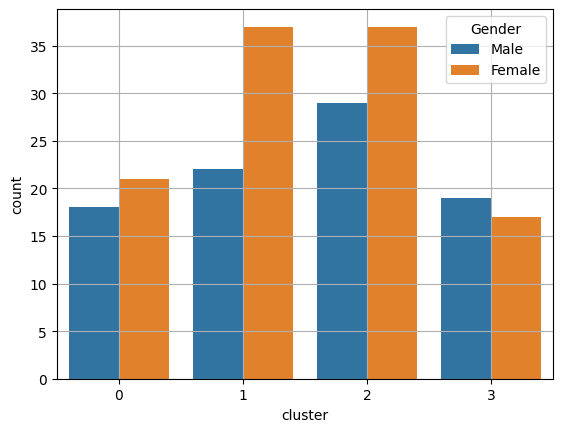

In [241]:
sns.countplot(data=data,x='cluster',hue='Gender')
plt.grid()

<Axes: ylabel='count'>

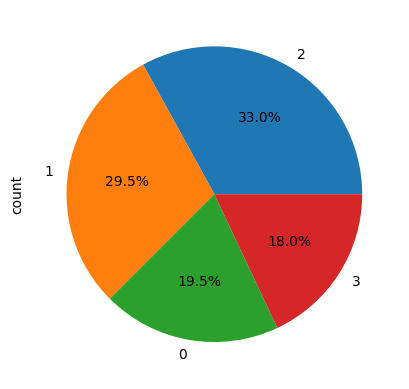

In [238]:
data['cluster'].value_counts().plot.pie(autopct='%0.1f%%')

<Axes: xlabel='cluster', ylabel='Spending Score (1-100)'>

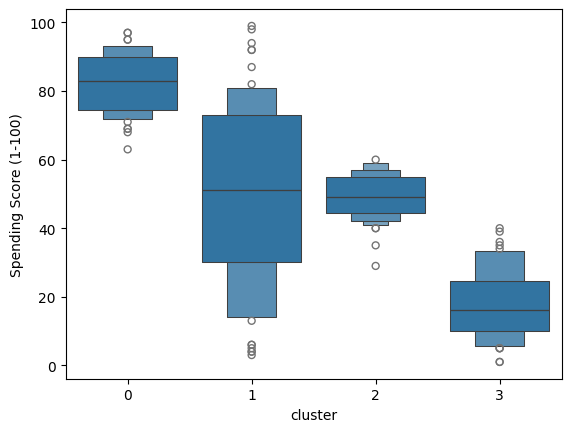

In [239]:
sns.boxenplot(data=data,x='cluster',y='Spending Score (1-100)')

<Axes: xlabel='Age', ylabel='Count'>

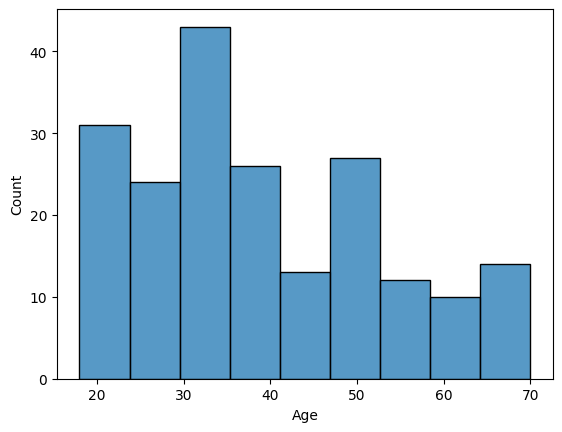

In [240]:
sns.histplot(data=data,x='Age')